# UNet++ Brain Tumor Segmentation

This notebook implements a **UNet++** model for brain tumor segmentation using the LGG Segmentation Dataset.

## Dataset
- **Source**: TCGA Lower Grade Glioma (LGG) collection
- **Format**: 4-channel multimodal MRI (T1 pre-contrast, T2-FLAIR, T1 post-contrast, T2)
- **Task**: Binary segmentation of FLAIR abnormality
- **Cases**: 110 patients with multiple slices per patient

## UNet++ Architecture
UNet++ is an improved version of U-Net with:
- Nested skip connections
- Deep supervision
- Better feature propagation
- Superior performance on medical imaging tasks

## 1. Import Libraries

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f'Using device: {device}')

Using device: mps


## 2. Data Exploration

In [40]:
# Set data paths (Kaggle environment paths)
DATA_DIR = Path('archive/kaggle_3m')
print(f"Dataset directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}")

# Get all patient folders
patient_folders = [f for f in DATA_DIR.iterdir() if f.is_dir() and f.name.startswith('TCGA')]
print(f"\nNumber of patients: {len(patient_folders)}")

# Collect all image and mask paths
image_paths = []
mask_paths = []

for patient_folder in patient_folders:
    images = sorted([f for f in patient_folder.glob('*.tif') if '_mask' not in f.name])
    masks = sorted([f for f in patient_folder.glob('*_mask.tif')])
    
    image_paths.extend(images)
    mask_paths.extend(masks)

print(f"\nTotal images: {len(image_paths)}")
print(f"Total masks: {len(mask_paths)}")

Dataset directory: archive/kaggle_3m
Directory exists: True

Number of patients: 110

Total images: 3929
Total masks: 3929


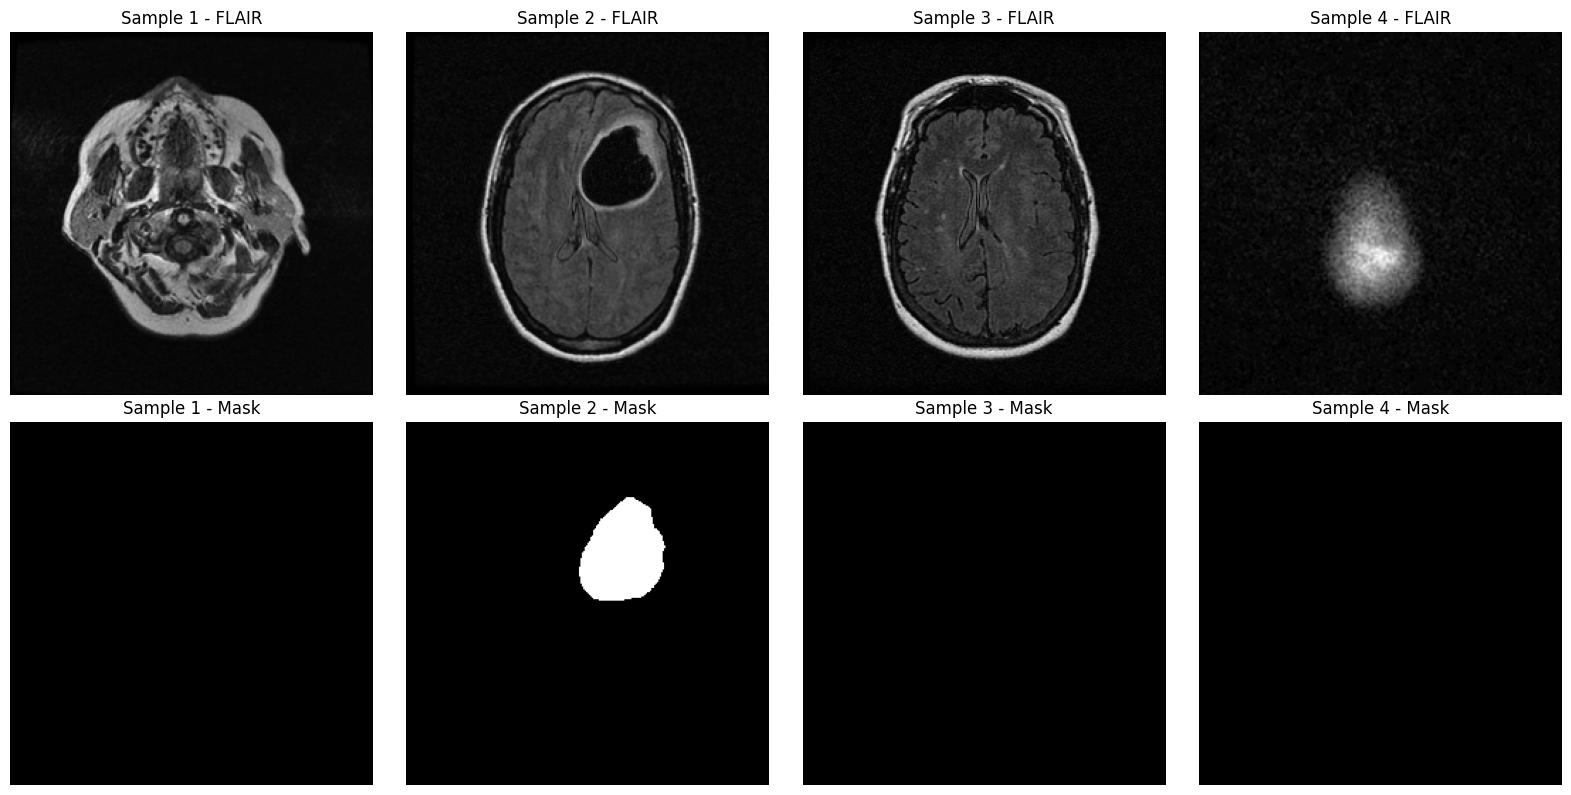


Image shape: (256, 256, 3)
Mask shape: (256, 256)
Unique mask values: [  0 255]


In [41]:
# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    idx = np.random.randint(0, len(image_paths))
    
    # Load image and mask
    img = np.array(Image.open(image_paths[idx]))
    mask = np.array(Image.open(mask_paths[idx]))
    
    # Display image (FLAIR channel)
    axes[0, i].imshow(img[:, :, 1], cmap='gray')
    axes[0, i].set_title(f'Sample {i+1} - FLAIR')
    axes[0, i].axis('off')
    
    # Display mask
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f'Sample {i+1} - Mask')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Check image dimensions
sample_img = np.array(Image.open(image_paths[0]))
sample_mask = np.array(Image.open(mask_paths[0]))
print(f"\nImage shape: {sample_img.shape}")
print(f"Mask shape: {sample_mask.shape}")
print(f"Unique mask values: {np.unique(sample_mask)}")

## 3. Custom Dataset Class

In [42]:
class BrainTumorDataset(Dataset):
    """Custom Dataset for Brain Tumor MRI images with albumentations support"""
    
    def __init__(self, image_paths, mask_paths, transform=None, img_size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.img_size = img_size
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image and mask
        image = np.array(Image.open(self.image_paths[idx]))
        mask = np.array(Image.open(self.mask_paths[idx]))
        
        # If image has 3 channels, duplicate one channel to create 4 channels
        # (T1-pre, FLAIR, T1-post) -> (T1-pre, FLAIR, T1-post, T2-approximation)
        if image.shape[-1] == 3:
            # Use FLAIR as approximation for T2 since they're similar
            t2_approx = image[:, :, 1:2]  # FLAIR channel
            image = np.concatenate([image, t2_approx], axis=-1)  # Now 4 channels
        
        # Normalize mask to binary
        mask = (mask > 0).astype(np.float32)
        
        # Apply albumentations transforms if provided
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']
            # Add channel dimension to mask after transform
            mask = mask.unsqueeze(0)
        else:
            # No transform: manual resize, normalize, and convert to tensor
            image = cv2.resize(image, (self.img_size, self.img_size))
            mask = cv2.resize(mask, (self.img_size, self.img_size))
            image = image.astype(np.float32) / 255.0
            image = torch.from_numpy(image).permute(2, 0, 1)
            mask = torch.from_numpy(mask).unsqueeze(0)
        
        return image, mask

## 5. Loss Functions and Metrics

In [43]:
class DiceLoss(nn.Module):
    """Dice Loss for binary segmentation"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        
        return 1 - dice


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
    
    def forward(self, pred, target):
        bce_loss = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        pred_prob = torch.sigmoid(pred)
        p_t = target * pred_prob + (1 - target) * (1 - pred_prob)
        focal_weight = (1 - p_t) ** self.gamma
        
        if self.alpha is not None:
            alpha_weight = target * self.alpha + (1 - target) * (1 - self.alpha)
            focal_weight = alpha_weight * focal_weight
        
        focal_loss = focal_weight * bce_loss
        return focal_loss.mean()


class CombinedLoss(nn.Module):
    """Hybrid Loss: Dice + Focal + BCE"""
    def __init__(self, dice_weight=0.5, focal_weight=0.3, bce_weight=0.2):
        super(CombinedLoss, self).__init__()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.bce_weight = bce_weight
        self.dice = DiceLoss()
        self.focal = FocalLoss(gamma=2.0)
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, pred, target):
        dice_loss = self.dice(pred, target)
        focal_loss = self.focal(pred, target)
        bce_loss = self.bce(pred, target)
        
        # Combine losses: 0.5 * Dice + 0.3 * Focal + 0.2 * BCE
        total_loss = (self.dice_weight * dice_loss + 
                     self.focal_weight * focal_loss + 
                     self.bce_weight * bce_loss)
        
        return total_loss


def dice_coefficient(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred = torch.sigmoid(pred) > threshold
    pred = pred.float()
    
    intersection = (pred * target).sum()
    dice = (2. * intersection) / (pred.sum() + target.sum() + 1e-6)
    
    return dice.item()


def iou_score(pred, target, threshold=0.5):
    """Calculate Intersection over Union (IoU)"""
    pred = torch.sigmoid(pred) > threshold
    pred = pred.float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = intersection / (union + 1e-6)
    
    return iou.item()
    

## 6. Data Preparation

In [44]:
# Split data into train/val/test
train_images, temp_images, train_masks, temp_masks = train_test_split(
    image_paths, mask_paths, test_size=0.3, random_state=42
)

val_images, test_images, val_masks, test_masks = train_test_split(
    temp_images, temp_masks, test_size=0.5, random_state=42
)

print(f"Training samples: {len(train_images)}")
print(f"Validation samples: {len(val_images)}")
print(f"Test samples: {len(test_images)}")

# Create datasets
IMG_SIZE = 256
BATCH_SIZE = 8

# Aggressive augmentation for medical images (training only)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    
    # Geometric augmentations
    A.Rotate(limit=20, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=20,
        p=0.7
    ),
    A.ElasticTransform(
        alpha=1,
        sigma=50,
        alpha_affine=50,
        p=0.3
    ),
    
    # Intensity augmentations
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    
    # Normalization
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

# Validation/Test transform (only resize and normalize, no augmentation)
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

train_dataset = BrainTumorDataset(train_images, train_masks, transform=train_transform, img_size=IMG_SIZE)
val_dataset = BrainTumorDataset(val_images, val_masks, transform=val_transform, img_size=IMG_SIZE)
test_dataset = BrainTumorDataset(test_images, test_masks, transform=val_transform, img_size=IMG_SIZE)

# Create dataloaders (num_workers=0 to avoid multiprocessing issues on macOS)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training samples: 2750
Validation samples: 589
Test samples: 590

Train batches: 344
Val batches: 74
Test batches: 74


## 6.1. Multimodal Data Sanity Check

Visualize all 4 modalities for sample images to verify data loading

MULTIMODAL DATA SANITY CHECK


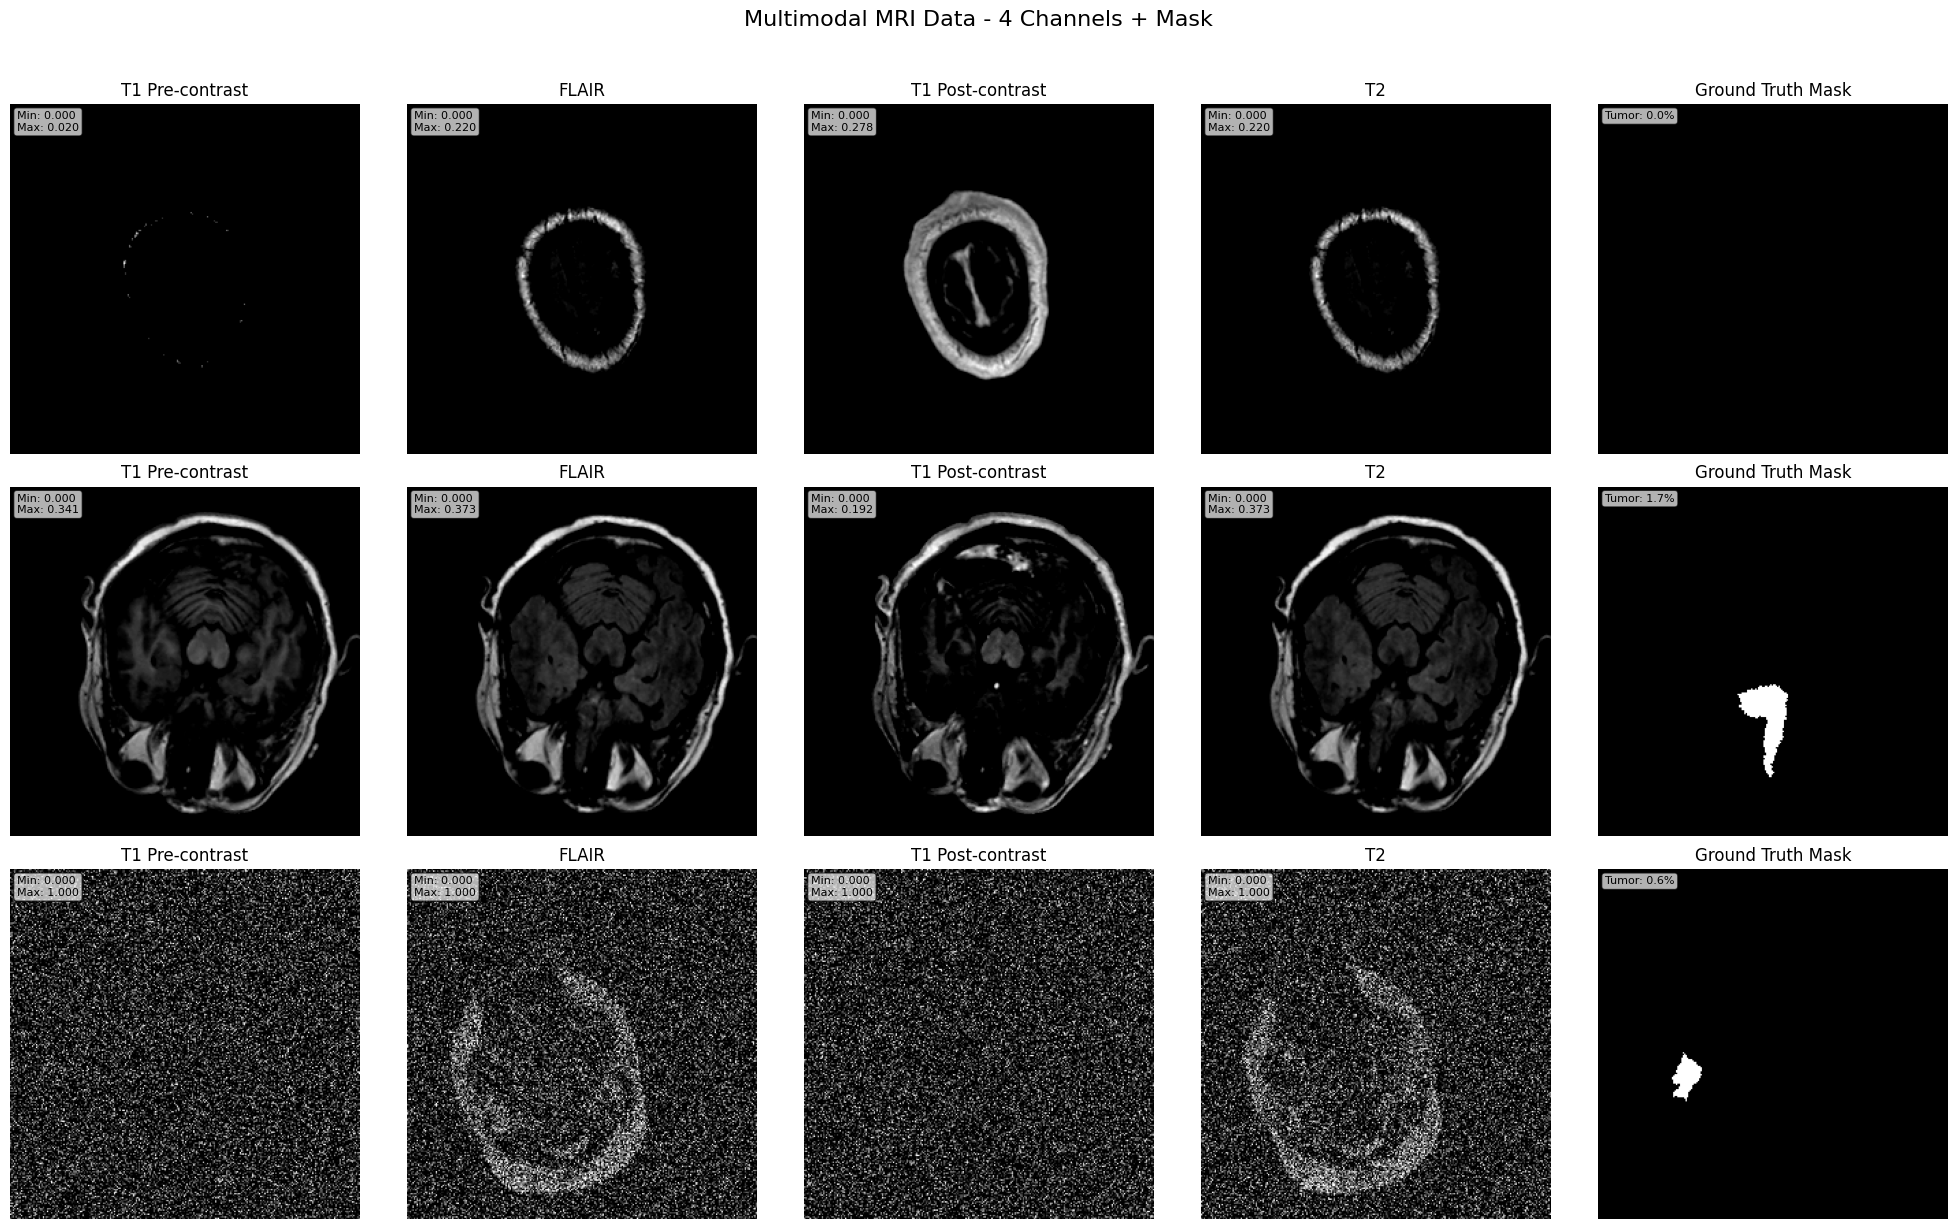


Data Shape Verification:
Image shape: torch.Size([4, 256, 256]) (Expected: [4, 256, 256])
Mask shape: torch.Size([1, 256, 256]) (Expected: [1, 256, 256])

Data Statistics:
T1 Pre-contrast      - Min: 0.0000, Max: 1.0000, Mean: 0.1530
FLAIR                - Min: 0.0000, Max: 1.0000, Mean: 0.1767
T1 Post-contrast     - Min: 0.0000, Max: 1.0000, Mean: 0.1512
T2                   - Min: 0.0000, Max: 1.0000, Mean: 0.1786
Mask                 - Unique values: [0. 1.], Tumor pixels: 417/65536


In [45]:
# Sanity check: Visualize multimodal data
print("="*60)
print("MULTIMODAL DATA SANITY CHECK")
print("="*60)

# Get a few samples from training dataset
num_samples = 3
sample_indices = np.random.choice(len(train_dataset), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples * 4))

modality_names = ['T1 Pre-contrast', 'FLAIR', 'T1 Post-contrast', 'T2', 'Ground Truth Mask']

for row, idx in enumerate(sample_indices):
    # Get sample
    image, mask = train_dataset[idx]
    
    # Convert from tensor to numpy
    image_np = image.numpy()  # Shape: (4, H, W)
    mask_np = mask.numpy()[0]  # Shape: (H, W)
    
    # Visualize each modality
    for col in range(4):
        axes[row, col].imshow(image_np[col], cmap='gray')
        axes[row, col].set_title(f'{modality_names[col]}')
        axes[row, col].axis('off')
        
        # Add min/max values for verification
        axes[row, col].text(
            0.02, 0.98, 
            f'Min: {image_np[col].min():.3f}\nMax: {image_np[col].max():.3f}',
            transform=axes[row, col].transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )
    
    # Visualize mask
    axes[row, 4].imshow(mask_np, cmap='gray')
    axes[row, 4].set_title(modality_names[4])
    axes[row, 4].axis('off')
    
    # Add tumor percentage
    tumor_percentage = (mask_np.sum() / mask_np.size) * 100
    axes[row, 4].text(
        0.02, 0.98, 
        f'Tumor: {tumor_percentage:.1f}%',
        transform=axes[row, 4].transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

plt.suptitle('Multimodal MRI Data - 4 Channels + Mask', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('multimodal_sanity_check.png', dpi=300, bbox_inches='tight')
plt.show()

# Verify data shapes and statistics
print(f"\nData Shape Verification:")
print(f"Image shape: {image.shape} (Expected: [4, {IMG_SIZE}, {IMG_SIZE}])")
print(f"Mask shape: {mask.shape} (Expected: [1, {IMG_SIZE}, {IMG_SIZE}])")
print(f"\nData Statistics:")
for i, name in enumerate(modality_names[:4]):
    print(f"{name:20s} - Min: {image_np[i].min():.4f}, Max: {image_np[i].max():.4f}, Mean: {image_np[i].mean():.4f}")
print(f"{'Mask':20s} - Unique values: {np.unique(mask_np)}, Tumor pixels: {mask_np.sum():.0f}/{mask_np.size}")
print("="*60)

## 7. Model Initialization

In [46]:
# Initialize model with attention mechanism
# Using segmentation_models_pytorch with all 4 MRI sequences
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",  # Better encoder
    encoder_weights=None,             # No ImageNet pre-training for medical images
    in_channels=4,                    # 4 MRI modalities: T1 pre-contrast, FLAIR, T1 post-contrast, T2
    classes=1,                        # Binary segmentation
    activation=None,                  # Use logits for loss calculation
    decoder_attention_type='scse'     # Spatial and Channel Squeeze & Excitation
).to(device)

# Loss function and optimizer
# Hybrid loss: 0.5 * Dice + 0.3 * Focal + 0.2 * BCE
criterion = CombinedLoss(dice_weight=0.5, focal_weight=0.3, bce_weight=0.2)

# Use AdamW optimizer with weight decay for better regularization
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,              # Start with higher learning rate
    weight_decay=1e-4,    # Regularization to prevent overfitting
    betas=(0.9, 0.999)
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ReduceLROnPlateau scheduler - monitors validation Dice score
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # Monitor DICE (higher is better)
    factor=0.5,          # Reduce LR by 50%
    patience=15,         # Wait 15 epochs before reducing
    min_lr=1e-7
)

Total parameters: 20,924,860
Trainable parameters: 20,924,860


## 8. Training Loop

In [47]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate metrics
        dice = dice_coefficient(outputs, masks)
        iou = iou_score(outputs, masks)
        
        running_loss += loss.item()
        running_dice += dice
        running_iou += iou
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Calculate metrics
            dice = dice_coefficient(outputs, masks)
            iou = iou_score(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou

In [48]:
# Training configuration
NUM_EPOCHS = 200  # Train much longer for better convergence
EARLY_STOPPING_PATIENCE = 50  # More patience before stopping
CHECKPOINT_INTERVAL = 10  # Save checkpoint every N epochs
CHECKPOINT_PATH = 'checkpoint.pth'

# Training history
history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': []
}

best_val_dice = 0.0
early_stopping_counter = 0
start_epoch = 0

# Load checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    history = checkpoint['history']
    best_val_dice = checkpoint['best_val_dice']
    early_stopping_counter = checkpoint['early_stopping_counter']
    print(f"✓ Resumed from epoch {start_epoch}")
    print(f"✓ Best validation Dice so far: {best_val_dice:.4f}\n")
else:
    print("No checkpoint found. Starting training from scratch...\n")

print("Starting training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_dice, train_iou = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_dice, val_iou = validate_epoch(model, val_loader, criterion, device)
    
    # Update scheduler - monitoring validation Dice score (higher is better)
    scheduler.step(val_dice)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_iou'].append(train_iou)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)
    
    # Print epoch summary
    print(f"\nTrain Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | Train IoU: {train_iou:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}")
    
    # Save best model
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), 'best_unet_plusplus.pth')
        print(f"✓ Best model saved! (Dice: {best_val_dice:.4f})")
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
    
    # Save checkpoint periodically
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_val_dice': best_val_dice,
            'early_stopping_counter': early_stopping_counter
        }
        torch.save(checkpoint, CHECKPOINT_PATH)
        print(f"💾 Checkpoint saved at epoch {epoch+1}")
    
    # Early stopping
    if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*50)
print(f"Training completed! Best Dice Score: {best_val_dice:.4f}")
print("="*50)

No checkpoint found. Starting training from scratch...

Starting training...


Epoch 1/200
--------------------------------------------------


KeyboardInterrupt: 

## 9. Training Visualization

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Dice Score
axes[1].plot(history['train_dice'], label='Train Dice')
axes[1].plot(history['val_dice'], label='Val Dice')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Training and Validation Dice Score')
axes[1].legend()
axes[1].grid(True)

# IoU Score
axes[2].plot(history['train_iou'], label='Train IoU')
axes[2].plot(history['val_iou'], label='Val IoU')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU Score')
axes[2].set_title('Training and Validation IoU Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Test Set Evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_unet_plusplus.pth'))

# Evaluate on test set
test_loss, test_dice, test_iou = validate_epoch(model, test_loader, criterion, device)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice Score: {test_dice:.4f}")
print(f"Test IoU Score: {test_iou:.4f}")
print("="*50)

## 11. Prediction Visualization

In [ ]:
def visualize_predictions(model, dataloader, device, num_samples=8):
    """Visualize model predictions"""
    model.eval()
    
    images_list = []
    masks_list = []
    preds_list = []
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            
            images_list.append(images.cpu())
            masks_list.append(masks.cpu())
            preds_list.append(preds.cpu())
            
            if len(images_list) * images.size(0) >= num_samples:
                break
    
    images = torch.cat(images_list, dim=0)[:num_samples]
    masks = torch.cat(masks_list, dim=0)[:num_samples]
    preds = torch.cat(preds_list, dim=0)[:num_samples]
    
    # Plot
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    
    for i in range(num_samples):
        # Original image (FLAIR channel)
        img = images[i, 1].numpy()  # FLAIR is channel 1
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('Input (FLAIR)')
        axes[i, 0].axis('off')
        
        # Ground truth
        mask = masks[i, 0].numpy()
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Prediction
        pred = preds[i, 0].numpy()
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        # Overlay
        overlay = np.stack([img, img, img], axis=-1)
        overlay[pred > 0] = [1, 0, 0]  # Red for prediction
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize predictions on test set
visualize_predictions(model, test_loader, device, num_samples=8)

## 12. Save Final Model

In [ ]:
# Save final model with metadata
torch.save({
    'epoch': len(history['train_loss']),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_dice': best_val_dice,
    'test_dice': test_dice,
    'test_iou': test_iou,
    'history': history
}, 'unet_plusplus_final.pth')

print("Final model saved successfully!")

## 13. Model Summary

In [ ]:
print("\n" + "="*60)
print("UNet++ MODEL SUMMARY")
print("="*60)
print(f"Architecture: UNet++ with Nested Skip Connections")
print(f"Input Size: {IMG_SIZE}x{IMG_SIZE}x4 (4 MRI modalities)")
print(f"Output: Binary segmentation mask")
print(f"Total Parameters: {total_params:,}")
print(f"\nTraining Data: {len(train_images)} samples")
print(f"Validation Data: {len(val_images)} samples")
print(f"Test Data: {len(test_images)} samples")
print(f"\nBest Validation Dice: {best_val_dice:.4f}")
print(f"Test Dice Score: {test_dice:.4f}")
print(f"Test IoU Score: {test_iou:.4f}")
print("="*60)